1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.


como x3 = 2x1+x2, então ela já depende das outras duas variáveis. então as duas devem proporcionar uma explicação sobre os dados

In [256]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la
import matplotlib.pyplot as plt

In [258]:
#Generate a dataset with 3 features each with N entries
N = 3000 #entende-se que é da ordem de 1000, então pode ser 2000,3000,etc

x1 = np.random.normal(loc=0.0, scale=1.0, size=N) #loc = mean; scale=std
x2 = x1 + np.random.normal(loc=0.0, scale=3.0, size=N)
x3 = 2*x1 + x2
dataset = np.column_stack((x1, x2, x3)).T #criar o dataset completo com as tres dimensões como feito no exercicio anterior
print(dataset.shape) #deve ter shape (N,3)

(3, 3000)


In [270]:
print(dataset)

[[-0.58372668  0.73097033 -0.01435468 ...  0.57434923 -1.09735013
   1.983723  ]
 [-4.36591258  3.44458954 -3.09823405 ...  2.87474719  0.10413567
   4.49722453]
 [-5.53336593  4.9065302  -3.12694341 ...  4.02344566 -2.09056458
   8.46467053]]


In [272]:
print(x1.mean(), x1.std()) #verificar se os dados estão coerentes N(0,1)
print((x2 - x1).mean(), (x2 - x1).std())  # isso é o ruído N(0,3)

0.018388375008456997 0.9849298347732811
-0.06565929375646933 3.003989616254126


In [274]:
#Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
dt_cent = dataset - dataset.mean(axis=0) #centralizar os dados em torno da origem para que não seja induzido pela localização
cov_matrix = np.cov(dt_cent)
print(cov_matrix,'\n')
l, v = la.eig(cov_matrix)
print(l.real,'\n',v,v.shape) #use .real -> delete "j" symbol

[[ 4.49292032 -1.56228737 -2.93063295]
 [-1.56228737  1.40946754  0.15281983]
 [-2.93063295  0.15281983  2.77781312]] 

[7.01607166e+00 1.19665287e-16 1.66412932e+00] 
 [[-0.79511039  0.57735027  0.18565058]
 [ 0.23677707  0.57735027 -0.78141109]
 [ 0.55833331  0.57735027  0.5957605 ]] (3, 3)


In [276]:
#Find the eigenvectors and eigenvalues using SVD. 
U, spectrum, Vt = np.linalg.svd(dt_cent)
v_svd = U
l_svd = spectrum**2/(N-1)
print(l_svd.real,'\n',v_svd,'\n',v_svd.shape)

#Check that the two procedures yield to same result
print(np.allclose(np.sort(l), np.sort(l_svd), atol = 0.05),'\n',np.allclose(np.sort(v_svd), np.sort(v),atol= 0.05))


[7.01707537e+00 1.66529229e+00 1.58196823e-31] 
 [[-0.79514785  0.18549006  0.57735027]
 [ 0.23693482 -0.78136327  0.57735027]
 [ 0.55821303  0.59587321  0.57735027]] 
 (3, 3)
True 
 True


In [278]:
#What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? 
l_sorted = l.real[np.argsort(l.real)[::-1]]
pct = l_sorted*100/l_sorted.sum()
cumulative = np.cumsum(pct)
print(l_sorted,'\n',pct,'\n',cumulative)

#Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
threshold = 99 # o limite aceito pelo exercicio
k = np.searchsorted(cumulative, threshold) + 1 #encontra a posição a qual o threshold pe atingido em cumulative, adiciona 1 pois a posição começa em zero
print("k =", k)


[7.01607166e+00 1.66412932e+00 1.19665287e-16] 
 [8.08284471e+01 1.91715529e+01 1.37860042e-15] 
 [ 80.8284471 100.        100.       ]
k = 2


The first principal component explains approximately 81.5% of the total variance, while the second explains about 18.5%. The third component explains nearly zero variance. This is expected since x3 is a linear combination of x1 and x2, meaning the dataset effectively lies in a two-dimensional subspace. Therefore retaining the first two components preserves more than 99% of the total variability.

In [280]:
#Redefine the data in the basis yielded by the PCA procedure
i = l.argsort()[::-1]
v_sorted = v[:, i]
data_pca = dt_cent.T @ v_sorted   
print(v_sorted,'\n',data_pca)
print(dt_cent.shape)
print(data_pca.shape)

[[-0.79511039  0.18565058  0.57735027]
 [ 0.23677707 -0.78141109  0.57735027]
 [ 0.55833331  0.5957605   0.57735027]] 
 [[-3.65908340e+00  6.64241196e-03  5.44284805e-16]
 [ 2.97387699e+00  3.67181519e-01 -3.57962475e-16]
 [-2.46805391e+00  5.55420096e-01  7.27979794e-16]
 ...
 [ 2.47042693e+00  2.57278961e-01 -3.10496272e-16]
 [-2.70060426e-01 -1.53057227e+00 -5.00495154e-16]
 [ 4.21366845e+00  1.89701460e+00 -2.32019029e-16]]
(3, 3000)
(3000, 3)


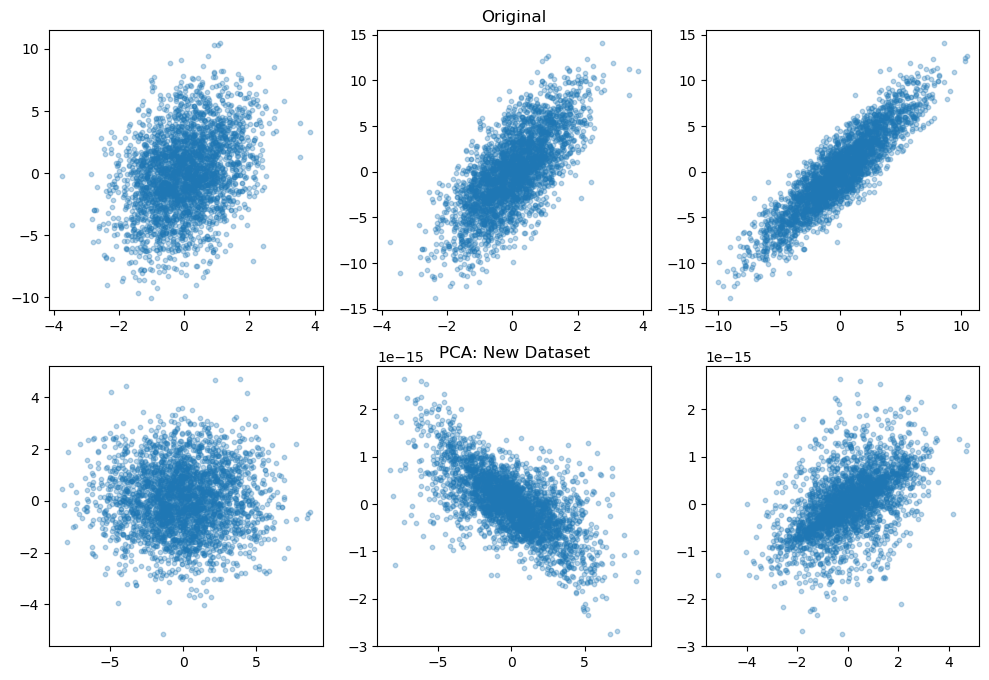

In [300]:
#Plot the data points in the original and the new coordiantes as a set of scatter plots. 

fig, axes = plt.subplots(2,3,figsize=(12,8))
dataset = dataset.T #deve ter shape N,3
dim = [(0,1),(0,2),(1,2)]
#para definir os de axes[0] usamos o dataset original
axes[0, 1].set_title("Original")
axes[1, 1].set_title("PCA: New Dataset")
for j, (a,b) in enumerate(dim):
    axes[0,j].scatter(dataset[:,a], dataset[:,b], alpha=0.3, s=10)
#para definir os de axes[1] usamos o dataset modelado a pca
    axes[1,j].scatter(data_pca[:,a], data_pca[:,b], alpha=0.3, s=10)


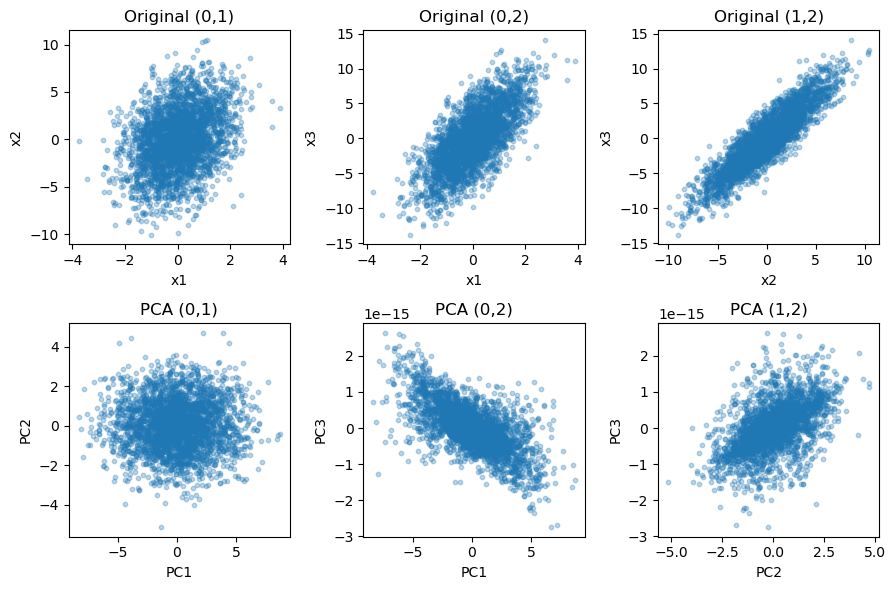

In [302]:
#Sugestão ChatGPT
# garantir formato (N,3)
X = dataset.T if dataset.shape[0] == 3 else dataset
Z = data_pca

pairs = [(0,1), (0,2), (1,2)]
titles = ["(0,1)", "(0,2)", "(1,2)"]

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

# ----- Linha 1: dados originais -----
for j, (a, b) in enumerate(pairs):
    axes[0, j].scatter(X[:, a], X[:, b], alpha=0.3, s=10)
    axes[0, j].set_title(f"Original {titles[j]}")
    axes[0, j].set_xlabel(f"x{a+1}")
    axes[0, j].set_ylabel(f"x{b+1}")

# ----- Linha 2: dados no PCA -----
for j, (a, b) in enumerate(pairs):
    axes[1, j].scatter(Z[:, a], Z[:, b], alpha=0.3, s=10)
    axes[1, j].set_title(f"PCA {titles[j]}")
    axes[1, j].set_xlabel(f"PC{a+1}")
    axes[1, j].set_ylabel(f"PC{b+1}")

plt.tight_layout()
plt.show()


2\. **PCA on a nD dataset**

Start from the dataset you have genereted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

In [314]:
#Creating 10 variables of noise
noise = np.random.normal(loc=0,scale=0.02,size=(N,10))
data_noise =  np.hstack((dataset, noise))
data_noise.shape

(3000, 13)

In [328]:
#Centralizing the data before running SVD
newdt_cent = data_noise - data_noise.mean(axis=0)
#SVD
U, spectrum, Vt = np.linalg.svd(newdt_cent.T)
v_svd = U
l_svd = spectrum**2/(N-1)
print(l_svd.real,'\n',v_svd,'\n',v_svd.shape)
#Check the percentages of variables and see if the noise made a difference
newl_sorted = l_svd.real[np.argsort(l_svd.real)[::-1]]
noisy_pct = newl_sorted*100/newl_sorted.sum()
new_cumulative = np.cumsum(noisy_pct)
print(newl_sorted,'\n',noisy_pct,'\n',new_cumulative)
#Test with the previous threshold(99) to see if the noise adds impotance
k = np.searchsorted(new_cumulative, threshold) + 1 
print("k =", k,"só x1 e x2 são pca")

[2.72469235e+01 1.92830904e+00 4.44150665e-04 4.30388802e-04
 4.23437628e-04 4.15238736e-04 4.14150847e-04 4.06135192e-04
 3.91077222e-04 3.86048757e-04 3.80355718e-04 3.57003695e-04
 1.28903998e-31] 
 [[-1.13757312e-01  5.66032024e-01 -5.74105191e-05  3.11012199e-04
   9.33574735e-05 -4.53027703e-05  2.05908544e-04 -2.23695161e-04
   1.56670909e-05  1.60046892e-04 -3.37052465e-04 -1.10417634e-04
  -8.16496581e-01]
 [-5.79487878e-01 -7.05355589e-01  6.74642942e-05 -4.89575547e-04
  -8.36823770e-05  5.53196343e-05 -2.63791626e-04  2.98697738e-04
  -7.57558890e-05 -2.06566089e-04  3.92160447e-04  1.02205018e-04
  -4.08248290e-01]
 [-8.07002503e-01  4.26708460e-01 -4.73567440e-05  1.32448850e-04
   1.03032570e-04 -3.52859063e-05  1.48025461e-04 -1.48692583e-04
  -4.44217072e-05  1.13527695e-04 -2.81944483e-04 -1.18630250e-04
   4.08248290e-01]
 [ 8.06540147e-05  4.16130930e-04 -5.04139230e-02 -4.88056338e-01
   3.78874455e-01 -4.13785673e-01 -1.96198052e-01 -3.69694975e-01
  -1.80055122e-

3 \. **Looking at an oscillating spring** (optional)

Imagine you have $n$ cameras looking at a spring oscillating along the $x$ axis. Each  camera record the motion of the spring looking at it along a given direction defined by the pair $(\theta_i, \phi_i)$, the angles in spherical coordinates. 

Start from the simulation of the records (say ${\cal O}(1000)$) of the spring's motion along the x axis, assuming a little random noise affects the measurements along the $y$. Rotate such dataset to emulate the records of each camera.

Perform a Principal Component Analysis on the thus obtained dataset, aiming at finding the only one coordinate that really matters.


4\. **PCA on the MAGIC dataset** (optional)

Perform a PCA on the magic04.data dataset

In [ ]:
# get the dataset and its description on the proper data directory
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data -P ~/data/
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names -P ~/data/ 